### Import libraries

In [2]:
### run this tab twice to remove warnings
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import os

### Import input data

In [3]:
filename_i = str(input("\n Enter file name with extension! "))
print(filename_i)
sep = str(input("\n Enter choice for separation: '\\t' for tab, '\s+' for space and ',' for comma, etc. : "))
df_res = pd.read_csv(filename_i,sep= sep,header=None,names=['R', 'a1', 'a2', 'a3', 'E'])    
df_res


 Enter file name with extension! 4D_PES_sparse.dat
4D_PES_sparse.dat

 Enter choice for separation: '\t' for tab, '\s+' for space and ',' for comma, etc. : ,


,R,a1,a2,a3,E
0,2.5,0,0,0,-76.975009
1,2.6,0,0,0,-76.974338
2,2.7,0,0,0,-76.974119
3,2.8,0,0,0,-76.974311
4,2.9,0,0,0,-76.974755
...,...,...,...,...,...
6200,7.6,90,90,180,-76.977659
6201,7.7,90,90,180,-76.977658
6202,7.8,90,90,180,-76.977657
6203,7.9,90,90,180,-76.977657


#### set path for input/output directory; 
input/output scaling and E_inf (Energy at infinity) are for visualization only. <br>
PESLearn takes input in Hartrees


In [4]:
# set path for input/output directory 
input_dir = os.getcwd()+'/'
out_peslearn = input_dir + 'peslearn_out/'

scaling = 5

Scales = [1,1000.0,27.211399,2625.5002,627.5096080,219474.63]
Scale_name = ['Ha.','mHa.','eV','kJ/mol','kcal/mol','cm⁻¹']

y_scale = Scale_name[5]
scal_param = Scales[5]

# coverting R to bohr
conver_au = 1.8897259886  # angstrom to bohr (not used in this example)

E_inf = -76.97764842

#### Trim very high energy points 
For the test dataset - Enter : 5600


 Enter the number of points to be retained in minima region                  (Any guess < total data points) : 
 5600


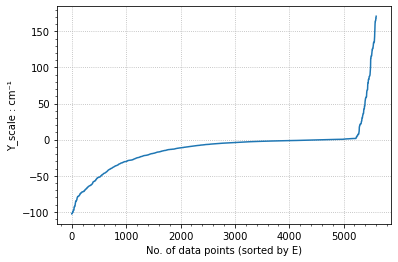

Num of data points after trimming =  5600


In [6]:
# visualizing to removing high energy data points
trim = int(input("\n Enter the number of points to be retained in minima region \
                 (Any guess < total data points) : \n "))

# SORTING BY ENERGY (NEEDED FOR SMOOTH CONVERGANCE IN PESLEARN)
df_pl = df_res.sort_values(by='E')
df_pl_trim = df_pl.iloc[:trim].reset_index(drop = True)

def pl_trim_vis(df_pl_tri,trim,Ef,sp,yn):
    z = (df_pl_tri.E.to_numpy()-Ef)*sp
    x = np.arange(trim)
    fig, ax = plt.subplots()
    plt.plot(x,z)
    plt.grid(True,linestyle=':')
    plt.minorticks_on()
    plt.xlabel('No. of data points (sorted by E)')
    plt.ylabel('Y_scale : ' + yn)
    plt.show()

pl_trim_vis(df_pl_trim,trim,E_inf,scal_param,y_scale)

print("Num of data points after trimming = ", trim)

In [7]:
# visualize final data must be in Hartree 
df_pl_trim

,R,a1,a2,a3,E
0,3.5,90,0,90,-76.978117
1,3.5,0,0,90,-76.978117
2,3.5,60,0,90,-76.978117
3,3.5,30,0,90,-76.978116
4,3.6,90,0,90,-76.978114
...,...,...,...,...,...
5595,2.9,60,90,150,-76.976882
5596,3.0,0,60,90,-76.976876
5597,3.0,90,60,60,-76.976875
5598,3.0,90,60,120,-76.976874


## PESLearn

In [8]:
import peslearn  # if error occurs, install utilities locally!

In [9]:
if not os.path.exists(out_peslearn):
    os.makedirs(out_peslearn)
os.chdir(out_peslearn) 

In [12]:
# visualize energy minimum - replace 4 with E column number
print(df_pl_trim[df_pl_trim.E == df_pl_trim.E.min()])

     R  a1  a2  a3          E
0  3.5  90   0  90 -76.978117
1  3.5   0   0  90 -76.978117


In [13]:
filename_n = "PESL.dat"
df_pl_trim.to_csv(out_peslearn+"/PESL.dat", index=None,sep=',')
print(filename_n)

Using_NN = int(input("\n Enter 1 for creating NN model and any other number for GP : \n "))

PESL.dat

 Enter 1 for creating NN model and any other number for GP : 
 1


#### model parameters 
80:10:10 (training: testing: validation) for NN<br>
80:20 (training:testing) for GP<br>
Sampling - Default: structure_based<br>
Rest of the parameters can be found here:<br>
https://github.com/CCQC/PES-Learn/blob/f066b2a480cb96e82695fdbe234724ba7be20f21/3_Keywords/keywords.md

In [14]:
if (Using_NN == 1):
    input_string = ("""
                   pes_format=zmat
                   use_pips = false
                   ml_model = nn
                   training_points = 4458  
                   validation_points = 557 
                   nn_precision = 64
                   eq_geom      : [3.5,0,0,90]
                   n_low_energy_train = 1
                   hp_maxit = 5  
                   """)
else: 
    input_string = ("""
                   pes_format=zmat
                   use_pips = false
                   ml_model = gp
                   hp_maxit = 10   
                   training_points = 500
                   eq_geom      : [90.0,3.2]
                   n_low_energy_train = 1
                   gp_ard=opt
                   """)

input_obj = peslearn.InputProcessor(input_string)


### create model

In [15]:
if Using_NN == 1 :
    nn = peslearn.ml.NeuralNetwork(filename_n, input_obj)
    nn.optimize_model()
else: 
    gp = peslearn.ml.GaussianProcess(filename_n, input_obj)
    gp.optimize_model()

Training with 4458 points. Validating with 557 points. Full dataset contains 5600 points.
Using structure_based training set point sampling.
Errors are root-mean-square error in wavenumbers (cm-1)

Performing neural architecture search...

Hidden layer structure:  (16,)
Hyperparameters:  {'morse_transform': {'morse': False}, 'scale_X': {'scale_X': 'std', 'activation': 'tanh'}, 'scale_y': 'std', 'pip': {'degree_reduction': False, 'pip': False}, 'layers': (16,)}
Test set RMSE (cm-1):  4.13  Validation set RMSE (cm-1):  4.57 Full dataset RMSE (cm-1):  5.24
Hidden layer structure:  (32,)
Hyperparameters:  {'morse_transform': {'morse': False}, 'scale_X': {'scale_X': 'std', 'activation': 'tanh'}, 'scale_y': 'std', 'pip': {'degree_reduction': False, 'pip': False}, 'layers': (32,)}
Test set RMSE (cm-1):  2.46  Validation set RMSE (cm-1):  2.76 Full dataset RMSE (cm-1):  2.81
Hidden layer structure:  (64,)
Hyperparameters:  {'morse_transform': {'morse': False}, 'scale_X': {'scale_X': 'std', 'ac

Test set RMSE (cm-1):  0.15  Validation set RMSE (cm-1):  0.12 Full dataset RMSE (cm-1):  0.10
Hyperparameters:  {'layers': (128, 128, 128), 'morse_transform': {'morse': False}, 'pip': {'pip': False}, 'scale_X': {'activation': 'tanh', 'scale_X': 'std'}, 'scale_y': 'mm11', 'lr': 0.6}
Test set RMSE (cm-1):  0.15  Validation set RMSE (cm-1):  0.78 Full dataset RMSE (cm-1):  0.27
Hyperparameters:  {'layers': (128, 128, 128), 'morse_transform': {'morse': False}, 'pip': {'pip': False}, 'scale_X': {'activation': 'tanh', 'scale_X': 'std'}, 'scale_y': 'mm11', 'lr': 0.5}
Test set RMSE (cm-1):  0.17  Validation set RMSE (cm-1):  0.44 Full dataset RMSE (cm-1):  0.17
Hyperparameters:  {'layers': (128, 128, 128), 'morse_transform': {'morse': False}, 'pip': {'pip': False}, 'scale_X': {'activation': 'tanh', 'scale_X': 'std'}, 'scale_y': 'mm11', 'lr': 0.4}
Test set RMSE (cm-1):  0.15  Validation set RMSE (cm-1):  0.24 Full dataset RMSE (cm-1):  0.12
Hyperparameters:  {'layers': (128, 128, 128), 'morse_

Epoch 173 Validation RMSE (cm-1):  0.97
Epoch 174 Validation RMSE (cm-1):  0.96
Epoch 175 Validation RMSE (cm-1):  0.96
Epoch 176 Validation RMSE (cm-1):  0.95
Epoch 177 Validation RMSE (cm-1):  0.95
Epoch 178 Validation RMSE (cm-1):  0.95
Epoch 179 Validation RMSE (cm-1):  0.95
Epoch 180 Validation RMSE (cm-1):  0.95
Epoch 181 Validation RMSE (cm-1):  0.94
Epoch 182 Validation RMSE (cm-1):  0.94
Epoch 183 Validation RMSE (cm-1):  0.94
Epoch 184 Validation RMSE (cm-1):  0.94
Epoch 185 Validation RMSE (cm-1):  0.94
Epoch 186 Validation RMSE (cm-1):  0.94
Epoch 187 Validation RMSE (cm-1):  0.94
Epoch 188 Validation RMSE (cm-1):  0.94
Epoch 189 Validation RMSE (cm-1):  0.93
Epoch 190 Validation RMSE (cm-1):  0.93
Epoch 191 Validation RMSE (cm-1):  0.92
Epoch 192 Validation RMSE (cm-1):  0.91
Epoch 193 Validation RMSE (cm-1):  0.91
Epoch 194 Validation RMSE (cm-1):  0.90
Epoch 195 Validation RMSE (cm-1):  0.90
Epoch 196 Validation RMSE (cm-1):  0.90
Epoch 197 Validation RMSE (cm-1):  0.89


Epoch 378 Validation RMSE (cm-1):  0.63
Epoch 379 Validation RMSE (cm-1):  0.63
Epoch 380 Validation RMSE (cm-1):  0.63
Epoch 381 Validation RMSE (cm-1):  0.63
Epoch 382 Validation RMSE (cm-1):  0.63
Epoch 383 Validation RMSE (cm-1):  0.62
Epoch 384 Validation RMSE (cm-1):  0.62
Epoch 385 Validation RMSE (cm-1):  0.62
Epoch 386 Validation RMSE (cm-1):  0.61
Epoch 387 Validation RMSE (cm-1):  0.61
Epoch 388 Validation RMSE (cm-1):  0.61
Epoch 389 Validation RMSE (cm-1):  0.61
Epoch 390 Validation RMSE (cm-1):  0.61
Epoch 391 Validation RMSE (cm-1):  0.61
Epoch 392 Validation RMSE (cm-1):  0.61
Epoch 393 Validation RMSE (cm-1):  0.61
Epoch 394 Validation RMSE (cm-1):  0.60
Epoch 395 Validation RMSE (cm-1):  0.60
Epoch 396 Validation RMSE (cm-1):  0.60
Epoch 397 Validation RMSE (cm-1):  0.60
Epoch 398 Validation RMSE (cm-1):  0.60
Epoch 399 Validation RMSE (cm-1):  0.60
Epoch 400 Validation RMSE (cm-1):  0.59
Epoch 401 Validation RMSE (cm-1):  0.59
Epoch 402 Validation RMSE (cm-1):  0.59


Epoch 583 Validation RMSE (cm-1):  0.45
Epoch 584 Validation RMSE (cm-1):  0.45
Epoch 585 Validation RMSE (cm-1):  0.45
Epoch 586 Validation RMSE (cm-1):  0.45
Epoch 587 Validation RMSE (cm-1):  0.45
Epoch 588 Validation RMSE (cm-1):  0.45
Epoch 589 Validation RMSE (cm-1):  0.45
Epoch 590 Validation RMSE (cm-1):  0.45
Epoch 591 Validation RMSE (cm-1):  0.44
Epoch 592 Validation RMSE (cm-1):  0.44
Epoch 593 Validation RMSE (cm-1):  0.44
Epoch 594 Validation RMSE (cm-1):  0.44
Epoch 595 Validation RMSE (cm-1):  0.44
Epoch 596 Validation RMSE (cm-1):  0.44
Epoch 597 Validation RMSE (cm-1):  0.44
Epoch 598 Validation RMSE (cm-1):  0.44
Epoch 599 Validation RMSE (cm-1):  0.44
Epoch 600 Validation RMSE (cm-1):  0.44
Epoch 601 Validation RMSE (cm-1):  0.44
Epoch 602 Validation RMSE (cm-1):  0.44
Epoch 603 Validation RMSE (cm-1):  0.44
Epoch 604 Validation RMSE (cm-1):  0.44
Epoch 605 Validation RMSE (cm-1):  0.44
Epoch 606 Validation RMSE (cm-1):  0.44
Epoch 607 Validation RMSE (cm-1):  0.44


...

Epoch 993 Validation RMSE (cm-1):  0.27
Epoch 994 Validation RMSE (cm-1):  0.27
Epoch 995 Validation RMSE (cm-1):  0.27
Epoch 996 Validation RMSE (cm-1):  0.27
Epoch 997 Validation RMSE (cm-1):  0.27
Epoch 998 Validation RMSE (cm-1):  0.27
Epoch 999 Validation RMSE (cm-1):  0.27
Epoch 1000 Validation RMSE (cm-1):  0.27
Epoch 1001 Validation RMSE (cm-1):  0.27
Epoch 1002 Validation RMSE (cm-1):  0.27
Epoch 1003 Validation RMSE (cm-1):  0.27
Epoch 1004 Validation RMSE (cm-1):  0.27
Epoch 1005 Validation RMSE (cm-1):  0.27
Epoch 1006 Validation RMSE (cm-1):  0.27
Epoch 1007 Validation RMSE (cm-1):  0.27
Epoch 1008 Validation RMSE (cm-1):  0.27
Epoch 1009 Validation RMSE (cm-1):  0.27
Epoch 1010 Validation RMSE (cm-1):  0.27
Epoch 1011 Validation RMSE (cm-1):  0.27
Epoch 1012 Validation RMSE (cm-1):  0.27
Epoch 1013 Validation RMSE (cm-1):  0.27
Epoch 1014 Validation RMSE (cm-1):  0.27
Epoch 1015 Validation RMSE (cm-1):  0.27
Epoch 1016 Validation RMSE (cm-1):  0.27
Epoch 1017 Validation R

Epoch 1193 Validation RMSE (cm-1):  0.21
Epoch 1194 Validation RMSE (cm-1):  0.21
Epoch 1195 Validation RMSE (cm-1):  0.20
Epoch 1196 Validation RMSE (cm-1):  0.20
Epoch 1197 Validation RMSE (cm-1):  0.20
Epoch 1198 Validation RMSE (cm-1):  0.20
Epoch 1199 Validation RMSE (cm-1):  0.20
Epoch 1200 Validation RMSE (cm-1):  0.20
Epoch 1201 Validation RMSE (cm-1):  0.20
Epoch 1202 Validation RMSE (cm-1):  0.20
Epoch 1203 Validation RMSE (cm-1):  0.20
Epoch 1204 Validation RMSE (cm-1):  0.20
Epoch 1205 Validation RMSE (cm-1):  0.20
Epoch 1206 Validation RMSE (cm-1):  0.20
Epoch 1207 Validation RMSE (cm-1):  0.20
Epoch 1208 Validation RMSE (cm-1):  0.20
Epoch 1209 Validation RMSE (cm-1):  0.20
Epoch 1210 Validation RMSE (cm-1):  0.20
Epoch 1211 Validation RMSE (cm-1):  0.20
Epoch 1212 Validation RMSE (cm-1):  0.20
Epoch 1213 Validation RMSE (cm-1):  0.20
Epoch 1214 Validation RMSE (cm-1):  0.19
Epoch 1215 Validation RMSE (cm-1):  0.19
Epoch 1216 Validation RMSE (cm-1):  0.19
Epoch 1217 Valid

Epoch 1393 Validation RMSE (cm-1):  0.15
Epoch 1394 Validation RMSE (cm-1):  0.15
Epoch 1395 Validation RMSE (cm-1):  0.15
Epoch 1396 Validation RMSE (cm-1):  0.15
Epoch 1397 Validation RMSE (cm-1):  0.15
Epoch 1398 Validation RMSE (cm-1):  0.15
Epoch 1399 Validation RMSE (cm-1):  0.15
Epoch 1400 Validation RMSE (cm-1):  0.15
Epoch 1401 Validation RMSE (cm-1):  0.15
Epoch 1402 Validation RMSE (cm-1):  0.15
Epoch 1403 Validation RMSE (cm-1):  0.15
Epoch 1404 Validation RMSE (cm-1):  0.15
Epoch 1405 Validation RMSE (cm-1):  0.15
Epoch 1406 Validation RMSE (cm-1):  0.15
Epoch 1407 Validation RMSE (cm-1):  0.14
Epoch 1408 Validation RMSE (cm-1):  0.14
Epoch 1409 Validation RMSE (cm-1):  0.14
Epoch 1410 Validation RMSE (cm-1):  0.14
Epoch 1411 Validation RMSE (cm-1):  0.14
Epoch 1412 Validation RMSE (cm-1):  0.14
Epoch 1413 Validation RMSE (cm-1):  0.14
Epoch 1414 Validation RMSE (cm-1):  0.14
Epoch 1415 Validation RMSE (cm-1):  0.14
Epoch 1416 Validation RMSE (cm-1):  0.14
Epoch 1417 Valid

Epoch 1593 Validation RMSE (cm-1):  0.12
Epoch 1594 Validation RMSE (cm-1):  0.12
Epoch 1595 Validation RMSE (cm-1):  0.12
Epoch 1596 Validation RMSE (cm-1):  0.12
Epoch 1597 Validation RMSE (cm-1):  0.12
Epoch 1598 Validation RMSE (cm-1):  0.12
Epoch 1599 Validation RMSE (cm-1):  0.12
Epoch 1600 Validation RMSE (cm-1):  0.12
Epoch 1601 Validation RMSE (cm-1):  0.12
Epoch 1602 Validation RMSE (cm-1):  0.12
Epoch 1603 Validation RMSE (cm-1):  0.12
Epoch 1604 Validation RMSE (cm-1):  0.12
Epoch 1605 Validation RMSE (cm-1):  0.12
Epoch 1606 Validation RMSE (cm-1):  0.12
Epoch 1607 Validation RMSE (cm-1):  0.12
Epoch 1608 Validation RMSE (cm-1):  0.12
Epoch 1609 Validation RMSE (cm-1):  0.12
Epoch 1610 Validation RMSE (cm-1):  0.12
Epoch 1611 Validation RMSE (cm-1):  0.12
Epoch 1612 Validation RMSE (cm-1):  0.12
Epoch 1613 Validation RMSE (cm-1):  0.12
Epoch 1614 Validation RMSE (cm-1):  0.12
Epoch 1615 Validation RMSE (cm-1):  0.12
Epoch 1616 Validation RMSE (cm-1):  0.12
Epoch 1617 Valid

Epoch 1781 Validation RMSE (cm-1):  0.12
Epoch 1782 Validation RMSE (cm-1):  0.12
Epoch 1783 Validation RMSE (cm-1):  0.12
Epoch 1784 Validation RMSE (cm-1):  0.12
Epoch 1785 Validation RMSE (cm-1):  0.12
Epoch 1786 Validation RMSE (cm-1):  0.12
Early stopping termination
Test set RMSE (cm-1):  0.15  Validation set RMSE (cm-1):  0.12 Full dataset RMSE (cm-1):  0.10
Model optimization complete. Saving final model...
Saving ML model data...
